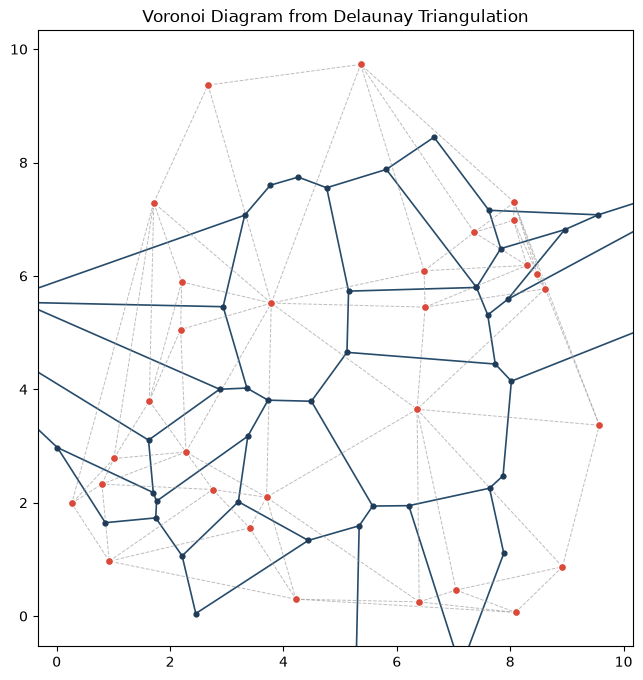

(2.7502931836911926, 2.2321073814882277)


In [33]:
from collections import Counter
import matplotlib.pyplot as plt
import random

# 边类
class Edge:
    """无向边，用作空腔边界统计"""

    __slots__ = ("a", "b")

    def __init__(self, a, b):
        self.a, self.b = (a, b) if a <= b else (b, a)

    def __eq__(self, other):
        return (
            isinstance(other, Edge)
            and self.a == other.a
            and self.b == other.b
        )

    def __hash__(self):
        return hash((self.a, self.b))


# 三角形类
class Triangle:
    __slots__ = ("a", "b", "c", "cx", "cy", "r2")

    def __init__(self, a, b, c):
        self.a = a
        self.b = b
        self.c = c
        self.cx, self.cy, self.r2 = circumcircle(a, b, c)

    def contains_in_circumcircle(self, p, eps=1e-10):
        """点 p 是否位于外接圆内或圆上"""
        dx = p[0] - self.cx
        dy = p[1] - self.cy
        dist2 = dx * dx + dy * dy
        tolerance = eps * max(1.0, self.r2)
        return dist2 <= self.r2 + tolerance

    def has_vertex(self, p):
        return p == self.a or p == self.b or p == self.c

# 外接圆计算
def circumcircle(a, b, c):
    """返回三角形的外接圆圆心和半径平方"""
    ax, ay = a
    bx, by = b
    cx, cy = c

    d = 2.0 * (
        ax * (by - cy)
        + bx * (cy - ay)
        + cx * (ay - by)
    )

    if abs(d) < 1e-12:
        raise ValueError("三点共线，无法构成三角形")

    ux = (
        (ax * ax + ay * ay) * (by - cy)
        + (bx * bx + by * by) * (cy - ay)
        + (cx * cx + cy * cy) * (ay - by)
    ) / d

    uy = (
        (ax * ax + ay * ay) * (cx - bx)
        + (bx * bx + by * by) * (ax - cx)
        + (cx * cx + cy * cy) * (bx - ax)
    ) / d

    r2 = (ux - ax) ** 2 + (uy - ay) ** 2
    return ux, uy, r2


# watson创建 delaunay 三角网算法
def bowyer_watson(points):
    """
    输入：
        points: [(x, y), ...]

    输出：
        triangles: [(p1, p2, p3), ...]
    """
    # 去除重复点
    pts = sorted(set((float(x), float(y)) for x, y in points))

    if len(pts) < 3:
        return []

    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    dx = max_x - min_x
    dy = max_y - min_y
    d = max(dx, dy, 1.0)

    mid_x = (min_x + max_x) / 2.0
    mid_y = (min_y + max_y) / 2.0

    # 构造包含所有点的超级三角形
    s1 = (mid_x - 30.0 * d, min_y - 30.0 * d)
    s2 = (mid_x + 30.0 * d, min_y - 30.0 * d)
    s3 = (mid_x, max_y + 30.0 * d)

    super_triangle = Triangle(s1, s2, s3)
    triangles = [super_triangle]

    for p in pts:
        # 找出外接圆包含当前点的所有三角形
        bad_triangles = [
            tri for tri in triangles
            if tri.contains_in_circumcircle(p)
        ]

        if not bad_triangles:
            # 非正常退化情况下可能发生
            continue

        # 统计空腔边界：
        # 只出现一次的内部边，就是空腔的边界边
        edge_count = Counter()

        for tri in bad_triangles:
            edge_count[Edge(tri.a, tri.b)] += 1
            edge_count[Edge(tri.b, tri.c)] += 1
            edge_count[Edge(tri.c, tri.a)] += 1

        boundary_edges = [
            edge for edge, count in edge_count.items()
            if count == 1
        ]

        # 删除非法三角形
        triangles = [
            tri for tri in triangles
            if tri not in bad_triangles
        ]

        # 用当前点和空腔边界构造新三角形
        for edge in boundary_edges:
            try:
                triangles.append(Triangle(edge.a, edge.b, p))
            except ValueError:
                # 三点共线，跳过退化三角形
                pass

    # 删除包含超级三角形顶点的三角形
    super_vertices = {s1, s2, s3}

    result = []
    for tri in triangles:
        if (
            tri.a not in super_vertices
            and tri.b not in super_vertices
            and tri.c not in super_vertices
        ):
            result.append((tri.a, tri.b, tri.c))

    return result



# 生成随机点
random.seed(42)

points = [
    (random.random() * 10, random.random() * 10)
    for _ in range(30)
]

triangles = bowyer_watson(points)

#
from collections import defaultdict
import math
import matplotlib.pyplot as plt


def orient(a, b, c):
    """判断三点方向"""
    return (
        (b[0] - a[0]) * (c[1] - a[1])
        - (b[1] - a[1]) * (c[0] - a[0])
    )


def voronoi_from_delaunay(triangles):
    """
    根据 Delaunay 三角网生成 Voronoi 图。

    返回：
        centers:      Voronoi 顶点
        finite_edges: 有限的 Voronoi 边
        rays:         无穷 Voronoi 射线
    """
    centers = []
    edge_map = defaultdict(list)

    # 1. 每个 Delaunay 三角形的外接圆心，就是一个 Voronoi 顶点
    for i, (a, b, c) in enumerate(triangles):
        ux, uy, _ = circumcircle(a, b, c)
        centers.append((ux, uy))

        for edge in ((a, b), (b, c), (c, a)):
            edge_map[Edge(*edge)].append((i, (a, b, c)))

    finite_edges = []
    rays = []

    # 2. 相邻 Delaunay 三角形 -> 有限 Voronoi 边
    #    凸包边 -> 无穷 Voronoi 射线
    for edge, data in edge_map.items():
        if len(data) == 2:
            i, _ = data[0]
            j, _ = data[1]
            finite_edges.append((centers[i], centers[j]))

        elif len(data) == 1:
            i, tri = data[0]
            a, b, c = tri
            cx, cy = centers[i]

            # 边方向
            dx = edge.b[0] - edge.a[0]
            dy = edge.b[1] - edge.a[1]

            # 选择远离第三个顶点的法线方向
            if orient(edge.a, edge.b, c) > 0:
                nx, ny = dy, -dx
            else:
                nx, ny = -dy, dx

            length = math.hypot(nx, ny)
            if length > 1e-12:
                nx /= length
                ny /= length
                rays.append(((cx, cy), (nx, ny)))

    return centers, finite_edges, rays



# 生成 Voronoi 数据
centers, finite_edges, rays = voronoi_from_delaunay(triangles)

# 开始绘图
plt.figure(figsize=(8, 8))

# 1. 绘制有限的 Voronoi 边
for p, q in finite_edges:
    plt.plot(
        [p[0], q[0]],
        [p[1], q[1]],
        color="#274c6b",
        linewidth=1.2
    )

# # 2. 绘制凸包外侧的 Voronoi 射线
# ray_length = 100.0
#
# for start, direction in rays:
#     x0, y0 = start
#     dx, dy = direction
#
#     plt.plot(
#         [x0, x0 + dx * ray_length],
#         [y0, y0 + dy * ray_length],
#         color="#274c6b",
#         linewidth=1.2
#     )

# 3. 可选：叠加原来的 Delaunay 三角网
# 如果不想显示 Delaunay 网，可以删除这一段
drawn_edges = set()

for a, b, c in triangles:
    for u, v in ((a, b), (b, c), (c, a)):
        key = tuple(sorted((u, v)))

        if key in drawn_edges:
            continue

        drawn_edges.add(key)

        plt.plot(
            [u[0], v[0]],
            [u[1], v[1]],
            color="#999999",
            linewidth=0.7,
            linestyle="--",
            alpha=0.65
        )

# 4. 绘制 Voronoi 顶点
if centers:
    plt.scatter(
        [p[0] for p in centers],
        [p[1] for p in centers],
        s=12,
        c="#1f3b57",
        zorder=4
    )

# 5. 绘制原始站点
plt.scatter(
    [p[0] for p in points],
    [p[1] for p in points],
    s=32,
    c="#d94a3a",
    edgecolors="white",
    linewidths=0.8,
    zorder=5
)

# 设置坐标范围
xs = [p[0] for p in points]
ys = [p[1] for p in points]
padding = 0.6

plt.xlim(min(xs) - padding, max(xs) + padding)
plt.ylim(min(ys) - padding, max(ys) + padding)

plt.gca().set_aspect("equal")
plt.title("Voronoi Diagram from Delaunay Triangulation")

plt.savefig(
    "voronoi_from_delaunay.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
# print("点数：", len(points))
# print("三角形数：", len(triangles))
#
# # 绘制 Delaunay 三角网
# fig= plt.subplots(figsize=(8, 8))
#
# for a, b, c in triangles:
#     plt.plot(
#         [a[0], b[0], c[0], a[0]],
#         [a[1], b[1], c[1], a[1]],
#         color="#274c6b",
#         linewidth=1.0
#     )
#
# # 只绘制点，不连接点
# plt.scatter(
#     [p[0] for p in points],
#     [p[1] for p in points],
#     s=28,
#     c="#d94a3a",
#     edgecolors="white",
#     linewidths=0.8,
#     zorder=3
# )
#
# # 设置画布范围
# ticks = [i for i in range(0,11)]
# plt.xticks(ticks)
# plt.yticks(ticks)
# plt.xlim(0,10)
# plt.ylim(0,10)
#
# #  添加标题
# plt.title("Delaunay Triangulation")
# plt.show()
